<a href="https://colab.research.google.com/github/spoorti2123/Weather_app/blob/main/heptatis1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SPOORTI
#1AJ22CS154
#COMPUTER SCIENCE AND ENGINEERING

MAIL : spoortin24@gmail.com

**Hepatitis** Disease Risk Prediction

Dataset: UCI Hepatitis Dataset (Kaggle)
Language: Python
Libraries: Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Keras

STEP 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Install and Import for fetching UCI dataset
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

STEP 2: Load Dataset

In [ ]:
# Fetch the UCI Hepatitis dataset
hepatitis = fetch_ucirepo(id=46)

# Extract features and target
features_df = hepatitis.data.features.copy()
target_series = hepatitis.data.targets.iloc[:, 0].copy()

# Normalize column names for features (as done in the 'python.py' script)
features_df.columns = (
    features_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Map target (Class: 1 = Dies, 2 = Lives) to 0/1 and rename to 'Category'
# This aligns with the 'Category' column expected by subsequent cells.
target_series = target_series.map({1: 0, 2: 1})
df = pd.concat([features_df, target_series.rename('Category')], axis=1)

df.head()

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,Category
0,30,2,1.0,2,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,85.0,18.0,4.0,NaN,1,1
1,50,1,1.0,2,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,0.9,135.0,42.0,3.5,NaN,1,1
2,78,1,2.0,2,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,96.0,32.0,4.0,NaN,1,1
3,31,1,NaN,1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,46.0,52.0,4.0,80.0,1,1
4,34,1,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,200.0,4.0,NaN,1,1


STEP 3: Dataset Information

In [ ]:
df.info()
df.describe()
df.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              155 non-null    int64  
 1   sex              155 non-null    int64  
 2   steroid          154 non-null    float64
 3   antivirals       155 non-null    int64  
 4   fatigue          154 non-null    float64
 5   malaise          154 non-null    float64
 6   anorexia         154 non-null    float64
 7   liver_big        145 non-null    float64
 8   liver_firm       144 non-null    float64
 9   spleen_palpable  150 non-null    float64
 10  spiders          150 non-null    float64
 11  ascites          150 non-null    float64
 12  varices          150 non-null    float64
 13  bilirubin        149 non-null    float64
 14  alk_phosphate    126 non-null    float64
 15  sgot             151 non-null    float64
 16  albumin          139 non-null    float64
 17  protime         

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,Category
0,30,2,1.0,2,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,85.0,18.0,4.0,NaN,1,1
1,50,1,1.0,2,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,0.9,135.0,42.0,3.5,NaN,1,1
2,78,1,2.0,2,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,96.0,32.0,4.0,NaN,1,1
3,31,1,NaN,1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,46.0,52.0,4.0,80.0,1,1
4,34,1,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,200.0,4.0,NaN,1,1


In [ ]:
df['Category'] = df['Category'].astype(object)

print("Data types after converting 'Category' to object:")
df.info()

print("\nFirst 5 rows after converting 'Category' to object:")
df.head()

Data types after converting 'Category' to object:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              155 non-null    float64
 1   sex              155 non-null    float64
 2   steroid          155 non-null    float64
 3   antivirals       155 non-null    float64
 4   fatigue          155 non-null    float64
 5   malaise          155 non-null    float64
 6   anorexia         155 non-null    float64
 7   liver_big        155 non-null    float64
 8   liver_firm       155 non-null    float64
 9   spleen_palpable  155 non-null    float64
 10  spiders          155 non-null    float64
 11  ascites          155 non-null    float64
 12  varices          155 non-null    float64
 13  bilirubin        155 non-null    float64
 14  alk_phosphate    155 non-null    float64
 15  sgot             155 non-null    float64
 16  albumin     

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,Category
0,30.0,2.0,1.000000,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,85.000000,18.0,4.0,61.852273,1.0,1
1,50.0,1.0,1.000000,2.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,0.9,135.000000,42.0,3.5,61.852273,1.0,1
2,78.0,1.0,2.000000,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,96.000000,32.0,4.0,61.852273,1.0,1
3,31.0,1.0,1.506494,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,46.000000,52.0,4.0,80.000000,1.0,1
4,34.0,1.0,2.000000,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,105.325397,200.0,4.0,61.852273,1.0,1


Numerical columns identified: ['age', 'bilirubin', 'alk_phosphate', 'sgot', 'albumin', 'protime']
Categorical/Binary columns identified: ['sex', 'steroid', 'antivirals', 'fatigue', 'malaise', 'anorexia', 'liver_big', 'liver_firm', 'spleen_palpable', 'spiders', 'ascites', 'varices', 'histology', 'Category']


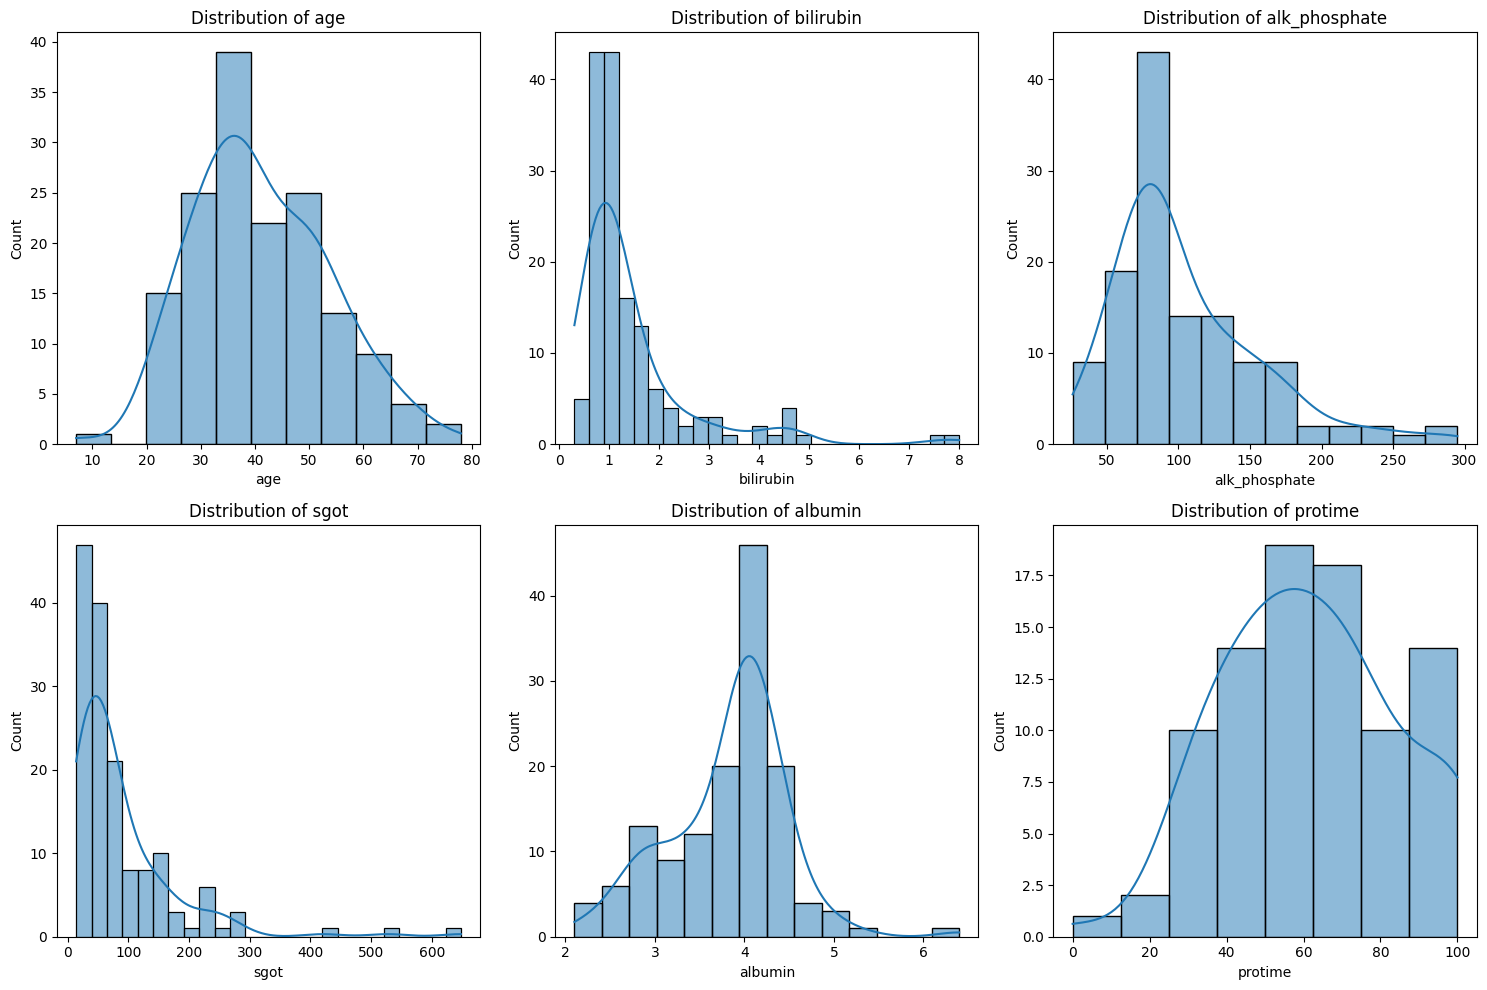

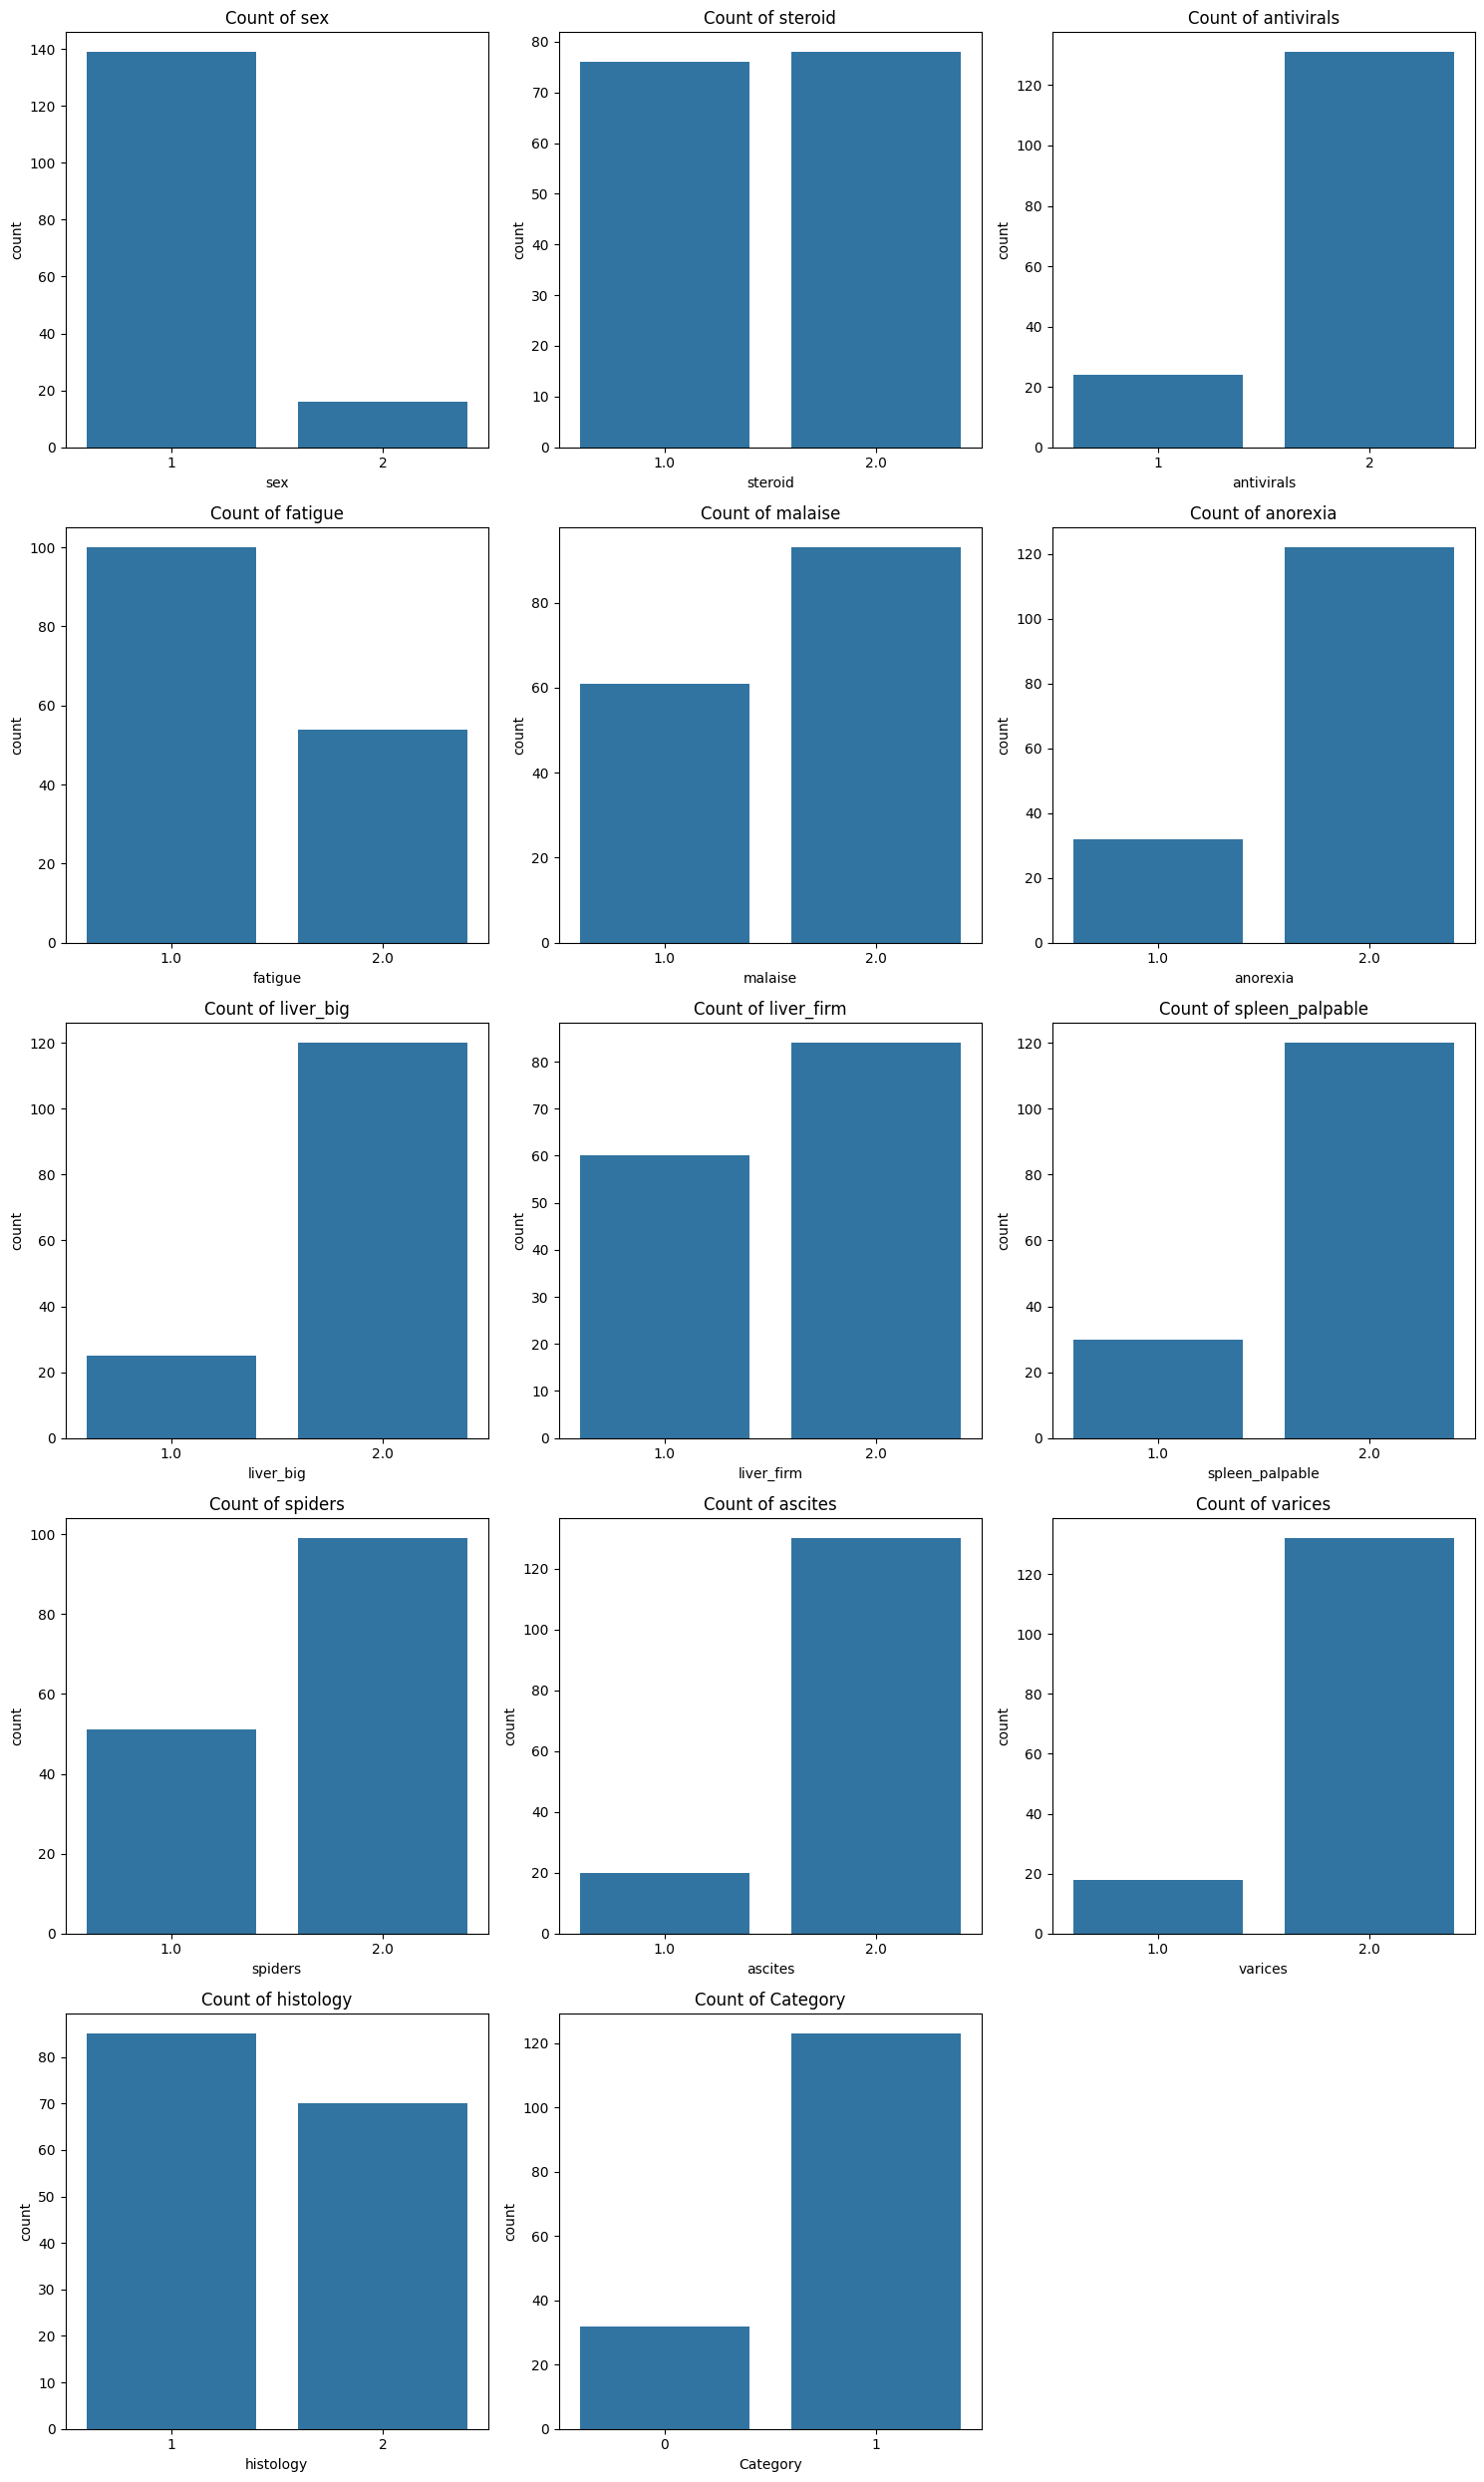

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical and categorical columns for plotting
# We'll consider columns with a limited number of unique values as categorical,
# even if they are stored as float, as they represent discrete choices.
numerical_cols = []
categorical_cols = []

for col in df.columns:
    if df[col].nunique() < 10 and col != 'age': # Heuristic for categorical/binary columns, excluding 'age'
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

print(f"Numerical columns identified: {numerical_cols}")
print(f"Categorical/Binary columns identified: {categorical_cols}")

# Plot histograms for numerical columns
if numerical_cols:
    plt.figure(figsize=(15, 5 * ((len(numerical_cols) + 2) // 3)))
    for i, col in enumerate(numerical_cols):
        plt.subplot(((len(numerical_cols) + 2) // 3), 3, i + 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

# Plot countplots for categorical/binary columns
if categorical_cols:
    plt.figure(figsize=(15, 5 * ((len(categorical_cols) + 2) // 3)))
    for i, col in enumerate(categorical_cols):
        plt.subplot(((len(categorical_cols) + 2) // 3), 3, i + 1)
        sns.countplot(x=df[col])
        plt.title(f'Count of {col}')
    plt.tight_layout()
    plt.show()

STEP 4: Missing Value Analysis

In [ ]:

df.isnull().sum()


,0
age,0
sex,0
steroid,1
antivirals,0
fatigue,1
malaise,1
anorexia,1
liver_big,10
liver_firm,11
spleen_palpable,5


Missing Value Visualization

/tmp/ipython-input-3757150730.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='viridis')


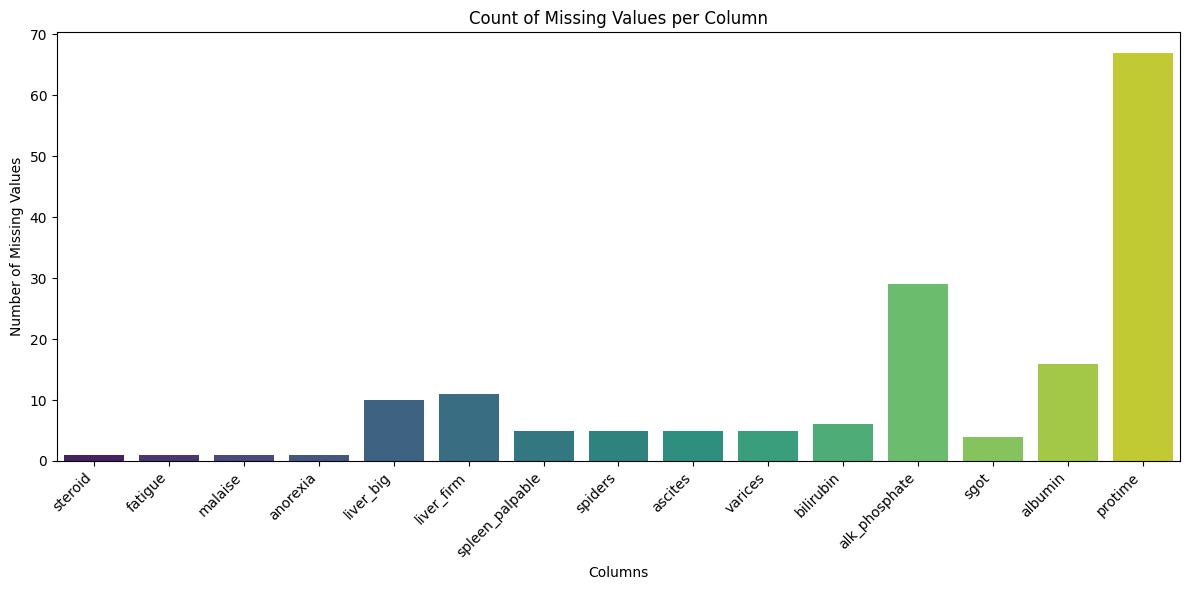

In [ ]:
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0] # Filter out columns with no missing values

if not missing_counts.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='viridis')
    plt.title("Count of Missing Values per Column")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the DataFrame.")

STEP 5: Data Imputation
Numerical → Mean


Categorical → Most Frequent

In [ ]:
num_cols = df.select_dtypes(include=['float64','int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Only attempt categorical imputation if there are categorical columns
if not cat_cols.empty:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])
else:
    print("No object type columns found for categorical imputation.")

In [ ]:
print("Means of numerical columns after imputation:")
print(df[num_cols].mean())

Means of numerical columns after imputation:
age                      41.2
sex                  1.103226
steroid              1.506494
antivirals           1.845161
fatigue              1.350649
malaise              1.603896
anorexia             1.792208
liver_big            1.827586
liver_firm           1.583333
spleen_palpable           1.8
spiders                  1.66
ascites              1.866667
varices                  1.88
bilirubin            1.427517
alk_phosphate      105.325397
sgot                 85.89404
albumin              3.817266
protime             61.852273
histology            1.451613
Category             0.793548
dtype: object


STEP 6: Encoding Categorical Variables

In [ ]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])



STEP 7: Exploratory Data Analysis (EDA)

Target Variable Distribution

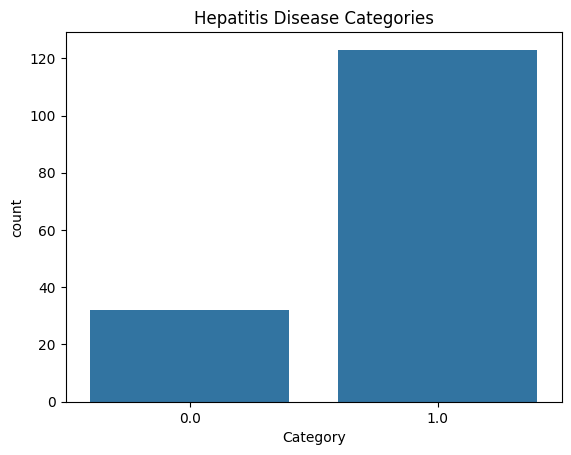

In [ ]:
sns.countplot(x='Category', data=df)
plt.title("Hepatitis Disease Categories")
plt.show()



Correlation Heatmap

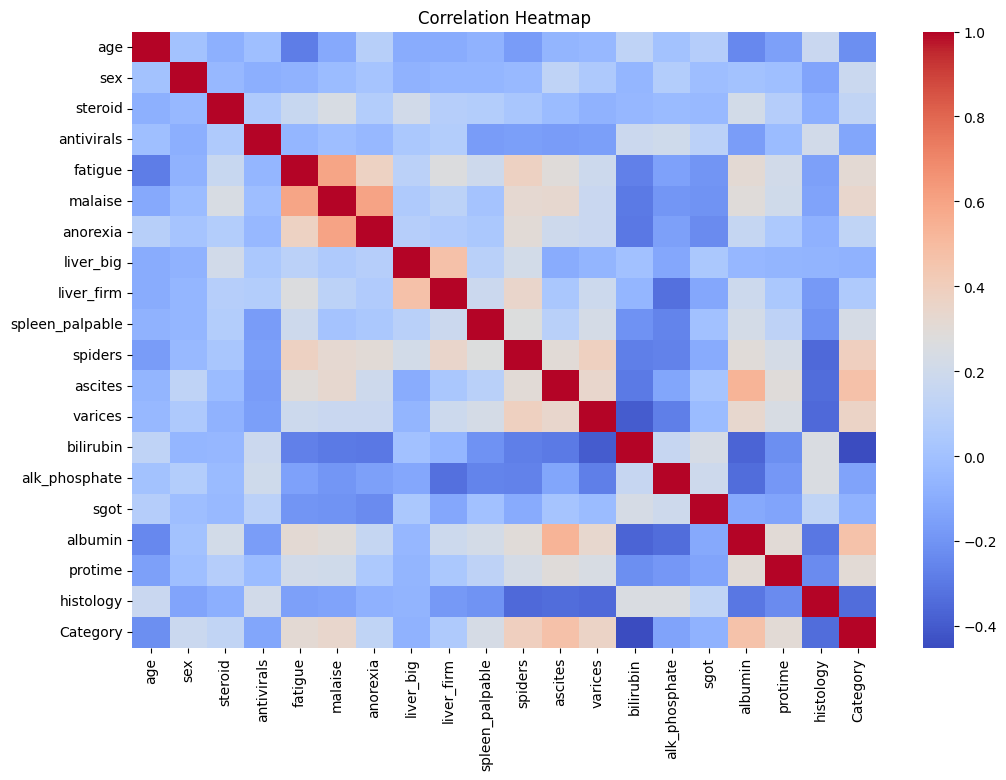

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


STEP 8: Feature Selection

In [ ]:
X = df.drop('Category', axis=1)
y = df['Category']


STEP 9: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


STEP 10: Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


PART 1: REGRESSION MODELS

Linear Regression

In [ ]:
from sklearn.metrics import accuracy_score

# Binarize the predictions from Linear Regression using a threshold of 0.5
y_pred_lr_binary = (y_pred_lr > 0.5).astype(int)

# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr_binary)
print(f"Accuracy of Linear Regression (with 0.5 threshold): {accuracy_lr}")

Accuracy of Linear Regression (with 0.5 threshold): 0.7419354838709677


PART 2: CONVENTIONAL CLASSIFICATION MODELS

Logistic Regression

In [ ]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_log))


Accuracy: 0.8064516129032258


Decision Tree

In [ ]:

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))


Accuracy: 0.5806451612903226


Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


Accuracy: 0.7419354838709677


Support Vector Machine (SVM)

In [ ]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))


Accuracy: 0.7096774193548387


Confusion Matrix

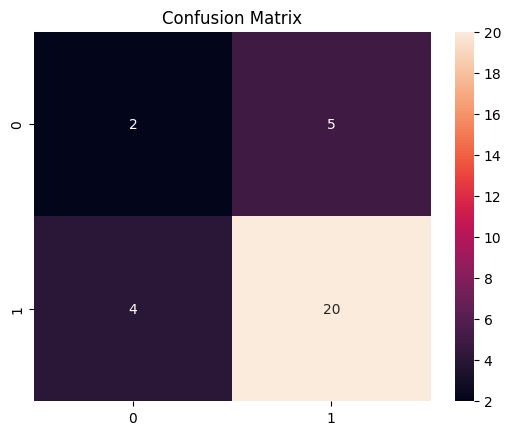

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


PART 3: NEURAL NETWORK CLASSIFICATION
 Import Keras

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Build Neural Network

In [ ]:
model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(16, activation='relu'))
model.add(Dense(len(np.unique(y)), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train Model

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6638 - loss: 0.6476
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7702 - loss: 0.5496 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7726 - loss: 0.5143 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8356 - loss: 0.4531 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8677 - loss: 0.4019 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8234 - loss: 0.4352 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8821 - loss: 0.3486 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8631 - loss: 0.3587 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8413 - loss: 0.3595 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8946 - loss: 0.2830 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8379 - loss: 0.3354 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8922 - loss: 0.2868 
Ep

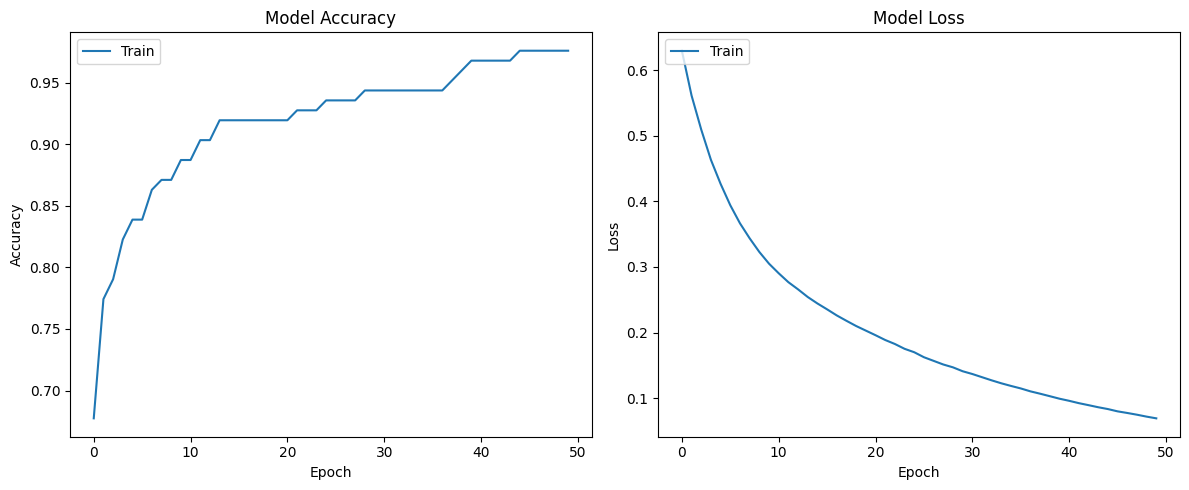

In [ ]:
history = model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)

# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9735 - loss: 0.0635 
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9707 - loss: 0.0621 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9580 - loss: 0.0679 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9586 - loss: 0.0733 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9893 - loss: 0.0539 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9836 - loss: 0.0672 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9836 - loss: 0.0535 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9802 - loss: 0.0587 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0509 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0367 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0483 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0358 
E

Evaluate Neural Network

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Neural Network Accuracy:", acc)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.7419 - loss: 0.8390
Neural Network Accuracy: 0.7419354915618896


python.py

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# =========================
# Config
# =========================
RANDOM_STATE = 42
N_SPLITS = 5
N_REPEATS = 10

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# =========================
# Load Dataset
# =========================
hepatitis = fetch_ucirepo(id=46)

X = hepatitis.data.features.copy()
y = hepatitis.data.targets.iloc[:, 0].copy()

# Normalize column names (CRITICAL)
X.columns = (
    X.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Target: 1 = Dies, 2 = Lives → 0/1
y = y.map({1: 0, 2: 1})

assert X.shape[1] == 19, "Expected 19 features"

# =========================
# Feature Typing
# =========================
NUMERIC_FEATURES = [
    "age",
    "bilirubin",
    "alk_phosphate",
    "sgot",
    "albumin",
    "protime"
]

BINARY_FEATURES = [
    "sex",
    "steroid",
    "antivirals",
    "fatigue",
    "malaise",
    "anorexia",
    "liver_big",
    "liver_firm",
    "spleen_palpable",
    "spiders",
    "ascites",
    "varices",
    "histology"
]

# Defensive check (prevents your error forever)
expected_cols = set(NUMERIC_FEATURES + BINARY_FEATURES)
actual_cols = set(X.columns)

assert expected_cols == actual_cols, (
    f"\nColumn mismatch!\nExpected: {expected_cols}\nGot: {actual_cols}"
)

# =========================
# Preprocessing Pipelines
# =========================
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, NUMERIC_FEATURES),
        ("bin", binary_pipeline, BINARY_FEATURES)
    ],
    remainder="drop"
)

# =========================
# Models (Constrained)
# =========================
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Linear SVM": SVC(
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance"
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.5,
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBClassifier(
        n_estimators=50,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=1.0,
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=RANDOM_STATE
    )
}

# =========================
# Cross-Validation
# =========================
cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# =========================
# Train & Evaluate
# =========================
results = []
best_model = None
best_auc = 0.0

for name, model in models.items():
    print(f"\nTraining: {name}")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv_results = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    mean_auc = cv_results["test_roc_auc"].mean()

    results.append({
        "Model": name,
        "Accuracy": cv_results["test_accuracy"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "F1": cv_results["test_f1"].mean(),
        "ROC-AUC": mean_auc
    })

    if mean_auc > best_auc:
        best_auc = mean_auc
        best_model = pipeline

# =========================
# Fit Best Model on Full Data
# =========================
best_model.fit(X, y)

# =========================
# Save Artifacts
# =========================
joblib.dump(best_model, f"{ARTIFACT_DIR}/best_model.pkl")
joblib.dump(preprocessor, f"{ARTIFACT_DIR}/preprocessor.pkl")

# =========================
# Results
# =========================
results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)

print("\n================ FINAL RESULTS ================\n")
print(results_df.to_string(index=False))


Training: Logistic Regression

Training: Linear SVM

Training: Random Forest

Training: KNN

Training: AdaBoost

Training: XGBoost

================ FINAL RESULTS ================

              Model  Accuracy  Precision   Recall       F1  ROC-AUC
      Random Forest  0.823871   0.912611 0.860767 0.884745 0.867971
                KNN  0.866452   0.886380 0.955367 0.918799 0.863979
            XGBoost  0.823226   0.831626 0.976533 0.897694 0.846414
Logistic Regression  0.805161   0.910040 0.837167 0.870333 0.846129
         Linear SVM  0.805806   0.909023 0.840600 0.871877 0.839243
           AdaBoost  0.841290   0.874158 0.935833 0.903328 0.838679


Precision :
Precision tells us how many predicted positive cases are actually correct.

Recall : Recall tells us how many actual positive cases we correctly identified.

F1-Score : F1-score is the balance between Precision and Recall.


In medical prediction:
Recall is very important (we should not miss sick patients).
But precision is also important (avoid wrong diagnosis).

In [ ]:
from sklearn.metrics import roc_curve, auc

print("roc_curve and auc functions imported successfully.")

roc_curve and auc functions imported successfully.


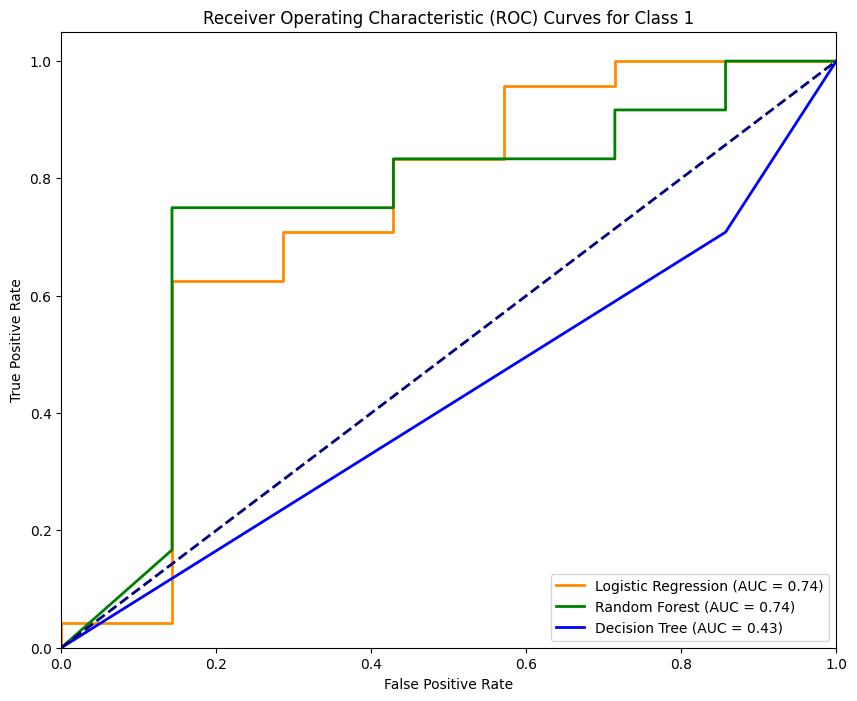

ROC curve comparison plot generated successfully.


In [ ]:
from sklearn.preprocessing import label_binarize

# Binarize y_test for multi-class ROC (one-vs-rest for class 1)
# Find all unique classes present in y_test
classes = np.unique(y_test)
# Check if '1' is one of the classes. If not, this approach might need adjustment or clarification.
if 1 not in classes:
    print(f"Warning: Class 1 not found in y_test. Unique classes are: {classes}")
    # If class 1 is truly not present, decide how to proceed.
    # For now, let's assume class 1 might be present, or we can adapt to plot for an existing class.
    # For this task, we will proceed assuming the intent is to evaluate against a specific 'positive' class if it exists.
    # If class 1 is not present, we will pick the first available class as the 'positive' class for demonstration.
    if classes.size > 0:
        positive_class_index = np.where(classes == classes[0])[0][0] # Index of the first class
        positive_class_label = classes[0]
        print(f"Plotting ROC for class {positive_class_label} as positive class.")
    else:
        raise ValueError("No classes found in y_test.")
else:
    positive_class_index = np.where(classes == 1)[0][0] # Index of class 1
    positive_class_label = 1

y_test_binarized = label_binarize(y_test, classes=classes)

# Calculate predicted probabilities for the positive class (class 1)
# Note: Assuming models were trained on multi-class data.
# Logistic Regression
y_pred_proba_log = log_reg.predict_proba(X_test)
# Random Forest
y_pred_proba_rf = rf.predict_proba(X_test)
# Decision Tree
y_pred_proba_dt = dt.predict_proba(X_test)

# Calculate FPR, TPR, and AUC for Logistic Regression (class 1)
fpr_log, tpr_log, _ = roc_curve(y_test_binarized[:, 0], y_pred_proba_log[:, positive_class_index])
roc_auc_log = auc(fpr_log, tpr_log)

# Calculate FPR, TPR, and AUC for Random Forest (class 1)
fpr_rf, tpr_rf, _ = roc_curve(y_test_binarized[:, 0], y_pred_proba_rf[:, positive_class_index])
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Calculate FPR, TPR, and AUC for Decision Tree (class 1)
fpr_dt, tpr_dt, _ = roc_curve(y_test_binarized[:, 0], y_pred_proba_dt[:, positive_class_index])
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_log, tpr_log, color='darkorange', lw=2, label='Logistic Regression (AUC = %0.2f)' % roc_auc_log)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label='Random Forest (AUC = %0.2f)' % roc_auc_rf)
plt.plot(fpr_dt, tpr_dt, color='blue', lw=2, label='Decision Tree (AUC = %0.2f)' % roc_auc_dt)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curves for Class {positive_class_label}')
plt.legend(loc='lower right')
plt.show()

print("ROC curve comparison plot generated successfully.")

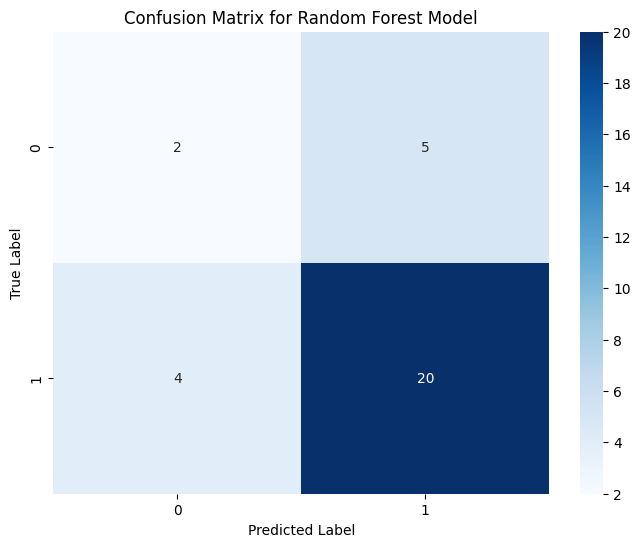

Confusion Matrix heatmap for Random Forest generated successfully.


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Random Forest Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Confusion Matrix heatmap for Random Forest generated successfully.")

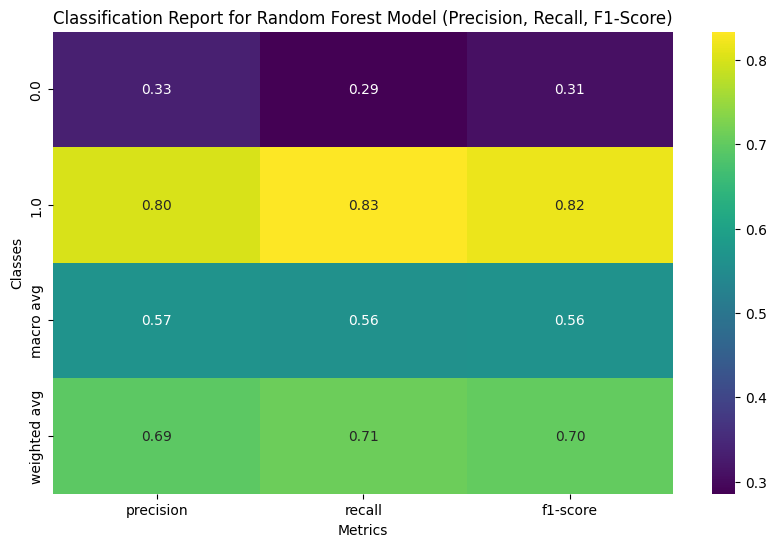

Classification report heatmap for Random Forest generated successfully.


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate classification report for Random Forest
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

# Convert to DataFrame for easier visualization
df_report_rf = pd.DataFrame(report_rf).transpose()

# Exclude 'accuracy' row and 'support' column for the heatmap if desired
# Or include them based on visual preference
df_report_rf_filtered = df_report_rf.drop(columns=['support'], errors='ignore')
if 'accuracy' in df_report_rf_filtered.index:
    df_report_rf_filtered = df_report_rf_filtered.drop('accuracy')

# Plotting the classification report as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_report_rf_filtered.iloc[:, :3], annot=True, cmap='viridis', fmt='.2f')
plt.title('Classification Report for Random Forest Model (Precision, Recall, F1-Score)')
plt.xlabel('Metrics')
plt.ylabel('Classes')
plt.show()

print("Classification report heatmap for Random Forest generated successfully.")

In [ ]:
pip install gradio


In [2]:
import joblib
import pandas as pd

# Define the artifact directory
ARTIFACT_DIR = 'artifacts'

# Load the best model globally so it's loaded only once
try:
    best_model_loaded = joblib.load(f"{ARTIFACT_DIR}/best_model.pkl")
    print("Best model loaded successfully.")
except FileNotFoundError:
    print(f"Error: Model file not found at {ARTIFACT_DIR}/best_model.pkl. Please ensure the model is trained and saved.")
    best_model_loaded = None

def predict_risk(
    age, sex, steroid, antivirals, fatigue, malaise, anorexia, liver_big, liver_firm,
    spleen_palpable, spiders, ascites, varices, bilirubin, alk_phosphate, sgot,
    albumin, protime, histology
):
    if best_model_loaded is None:
        return "Error: Model not loaded. Cannot make prediction."

    # Create a DataFrame from the input arguments
    input_data = pd.DataFrame([{
        'age': age,
        'sex': sex,
        'steroid': steroid,
        'antivirals': antivirals,
        'fatigue': fatigue,
        'malaise': malaise,
        'anorexia': anorexia,
        'liver_big': liver_big,
        'liver_firm': liver_firm,
        'spleen_palpable': spleen_palpable,
        'spiders': spiders,
        'ascites': ascites,
        'varices': varices,
        'bilirubin': bilirubin,
        'alk_phosphate': alk_phosphate,
        'sgot': sgot,
        'albumin': albumin,
        'protime': protime,
        'histology': histology
    }])

    # Get prediction probabilities
    # The target mapping was 1=Dies (0), 2=Lives (1)
    # So, index 0 is 'Dies', index 1 is 'Lives'
    prediction_proba = best_model_loaded.predict_proba(input_data)[0]

    prob_dies = prediction_proba[0]
    prob_lives = prediction_proba[1]

    if prob_lives > prob_dies:
        predicted_class = 'Lives'
        probability = prob_lives
    else:
        predicted_class = 'Dies'
        probability = prob_dies

    return f"Predicted: {predicted_class} (Probability: {probability:.1%})"

print("Prediction function 'predict_risk' defined.")

Error: Model file not found at artifacts/best_model.pkl. Please ensure the model is trained and saved.
Prediction function 'predict_risk' defined.


In [3]:
import os
import joblib
import numpy as np
import pandas as pd

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# =========================
# Config
# =========================
RANDOM_STATE = 42
N_SPLITS = 5
N_REPEATS = 10

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# =========================
# Load Dataset
# =========================
hepatitis = fetch_ucirepo(id=46)

X = hepatitis.data.features.copy()
y = hepatitis.data.targets.iloc[:, 0].copy()

# Normalize column names (CRITICAL)
X.columns = (
    X.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Target: 1 = Dies, 2 = Lives → 0/1
y = y.map({1: 0, 2: 1})

assert X.shape[1] == 19, "Expected 19 features"

# =========================
# Feature Typing
# =========================
NUMERIC_FEATURES = [
    "age",
    "bilirubin",
    "alk_phosphate",
    "sgot",
    "albumin",
    "protime"
]

BINARY_FEATURES = [
    "sex",
    "steroid",
    "antivirals",
    "fatigue",
    "malaise",
    "anorexia",
    "liver_big",
    "liver_firm",
    "spleen_palpable",
    "spiders",
    "ascites",
    "varices",
    "histology"
]

# Defensive check (prevents your error forever)
expected_cols = set(NUMERIC_FEATURES + BINARY_FEATURES)
actual_cols = set(X.columns)

assert expected_cols == actual_cols, (
    f"\nColumn mismatch!\nExpected: {expected_cols}\nGot: {actual_cols}"
)

# =========================
# Preprocessing Pipelines
# =========================
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, NUMERIC_FEATURES),
        ("bin", binary_pipeline, BINARY_FEATURES)
    ],
    remainder="drop"
)

# =========================
# Models (Constrained)
# =========================
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Linear SVM": SVC(
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance"
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.5,
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBClassifier(
        n_estimators=50,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=1.0,
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=RANDOM_STATE
    )
}

# =========================
# Cross-Validation
# =========================
cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# =========================
# Train & Evaluate
# =========================
results = []
best_model = None
best_auc = 0.0

for name, model in models.items():
    print(f"\nTraining: {name}")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv_results = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    mean_auc = cv_results["test_roc_auc"].mean()

    results.append({
        "Model": name,
        "Accuracy": cv_results["test_accuracy"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "F1": cv_results["test_f1"].mean(),
        "ROC-AUC": mean_auc
    })

    if mean_auc > best_auc:
        best_auc = mean_auc
        best_model = pipeline

# =========================
# Fit Best Model on Full Data
# =========================
best_model.fit(X, y)

# =========================
# Save Artifacts
# =========================
joblib.dump(best_model, f"{ARTIFACT_DIR}/best_model.pkl")
joblib.dump(preprocessor, f"{ARTIFACT_DIR}/preprocessor.pkl")

# =========================
# Results
# =========================
results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)

print("\n================ FINAL RESULTS ================\n")
print(results_df.to_string(index=False))


Training: Logistic Regression

Training: Linear SVM

Training: Random Forest

Training: KNN

Training: AdaBoost

Training: XGBoost

================ FINAL RESULTS ================

              Model  Accuracy  Precision   Recall       F1  ROC-AUC
      Random Forest  0.823871   0.912611 0.860767 0.884745 0.867971
                KNN  0.866452   0.886380 0.955367 0.918799 0.863979
            XGBoost  0.823226   0.831626 0.976533 0.897694 0.846414
Logistic Regression  0.805161   0.910040 0.837167 0.870333 0.846129
         Linear SVM  0.805806   0.909023 0.840600 0.871877 0.839243
           AdaBoost  0.841290   0.874158 0.935833 0.903328 0.838679


**Reasoning**:
The previous code block successfully generated the `best_model.pkl` file. Now, I will re-run the prediction function code, which should successfully load the model and define the prediction logic.



In [11]:
import joblib
import pandas as pd

# Define the artifact directory
ARTIFACT_DIR = 'artifacts'

# Load the best model globally so it's loaded only once
try:
    best_model_loaded = joblib.load(f"{ARTIFACT_DIR}/best_model.pkl")
    print("Best model loaded successfully.")
except FileNotFoundError:
    print(f"Error: Model file not found at {ARTIFACT_DIR}/best_model.pkl. Please ensure the model is trained and saved.")
    best_model_loaded = None

def predict_risk(
    age, sex, steroid, antivirals, fatigue, malaise, anorexia, liver_big, liver_firm,
    spleen_palpable, spiders, ascites, varices, bilirubin, alk_phosphate, sgot,
    albumin, protime, histology
):
    if best_model_loaded is None:
        return "Error: Model not loaded. Cannot make prediction."

    # Create a DataFrame from the input arguments
    input_data = pd.DataFrame([{
        'age': age,
        'sex': sex,
        'steroid': steroid,
        'antivirals': antivirals,
        'fatigue': fatigue,
        'malaise': malaise,
        'anorexia': anorexia,
        'liver_big': liver_big,
        'liver_firm': liver_firm,
        'spleen_palpable': spleen_palpable,
        'spiders': spiders,
        'ascites': ascites,
        'varices': varices,
        'bilirubin': bilirubin,
        'alk_phosphate': alk_phosphate,
        'sgot': sgot,
        'albumin': albumin,
        'protime': protime,
        'histology': histology
    }])

    # Get prediction probabilities
    # The target mapping was 1=Dies (0), 2=Lives (1)
    # So, index 0 is 'Dies', index 1 is 'Lives'
    prediction_proba = best_model_loaded.predict_proba(input_data)[0]

    prob_dies = prediction_proba[0]
    prob_lives = prediction_proba[1]

    if prob_lives > prob_dies:
        predicted_class = 'Lives'
        probability = prob_lives
    else:
        predicted_class = 'Dies'
        probability = prob_dies

    return f"Predicted: {predicted_class} (Probability: {probability:.1%})"

print("Prediction function 'predict_risk' defined.")

Best model loaded successfully.
Prediction function 'predict_risk' defined.


In [5]:
import gradio as gr

# Define the input components for Gradio
inputs = [
    gr.Slider(minimum=X['age'].min(), maximum=X['age'].max(), step=1, value=X['age'].mean(), label="Age"),
    gr.Radio(choices=[(f'Male ({int(1)})', 1), (f'Female ({int(2)})', 2)], value=X['sex'].mode()[0], label="Sex"),
    gr.Radio(choices=[(f'No ({int(1)})', 1), (f'Yes ({int(2)})', 2)], value=X['steroid'].mode()[0], label="Steroid Use"),
    gr.Radio(choices=[(f'No ({int(1)})', 1), (f'Yes ({int(2)})', 2)], value=X['antivirals'].mode()[0], label="Antivirals Use"),
    gr.Radio(choices=[(f'Yes ({int(1)})', 1), (f'No ({int(2)})', 2)], value=X['fatigue'].mode()[0], label="Fatigue"),
    gr.Radio(choices=[(f'Yes ({int(1)})', 1), (f'No ({int(2)})', 2)], value=X['malaise'].mode()[0], label="Malaise"),
    gr.Radio(choices=[(f'Yes ({int(1)})', 1), (f'No ({int(2)})', 2)], value=X['anorexia'].mode()[0], label="Anorexia"),
    gr.Radio(choices=[(f'No ({int(1)})', 1), (f'Yes ({int(2)})', 2)], value=X['liver_big'].mode()[0], label="Liver Big"),
    gr.Radio(choices=[(f'No ({int(1)})', 1), (f'Yes ({int(2)})', 2)], value=X['liver_firm'].mode()[0], label="Liver Firm"),
    gr.Radio(choices=[(f'No ({int(1)})', 1), (f'Yes ({int(2)})', 2)], value=X['spleen_palpable'].mode()[0], label="Spleen Palpable"),
    gr.Radio(choices=[(f'No ({int(1)})', 1), (f'Yes ({int(2)})', 2)], value=X['spiders'].mode()[0], label="Spiders"),
    gr.Radio(choices=[(f'No ({int(1)})', 1), (f'Yes ({int(2)})', 2)], value=X['ascites'].mode()[0], label="Ascites"),
    gr.Radio(choices=[(f'No ({int(1)})', 1), (f'Yes ({int(2)})', 2)], value=X['varices'].mode()[0], label="Varices"),
    gr.Number(minimum=X['bilirubin'].min(), maximum=X['bilirubin'].max(), value=X['bilirubin'].mean(), label="Bilirubin (mg/dl)"),
    gr.Number(minimum=X['alk_phosphate'].min(), maximum=X['alk_phosphate'].max(), value=X['alk_phosphate'].mean(), label="ALK Phosphate (mIU/ml)"),
    gr.Number(minimum=X['sgot'].min(), maximum=X['sgot'].max(), value=X['sgot'].mean(), label="SGOT (mIU/ml)"),
    gr.Number(minimum=X['albumin'].min(), maximum=X['albumin'].max(), value=X['albumin'].mean(), label="Albumin (g/dl)"),
    gr.Number(minimum=X['protime'].min(), maximum=X['protime'].max(), value=X['protime'].mean(), label="Protime"),
    gr.Radio(choices=[(f'No ({int(1)})', 1), (f'Yes ({int(2)})', 2)], value=X['histology'].mode()[0], label="Histology")
]

print("Gradio input components defined successfully.")

Gradio input components defined successfully.


In [12]:
iface = gr.Interface(
    fn=predict_risk,
    inputs=inputs,
    outputs="text",
    title="Hepatitis Disease Risk Prediction",
    description="Enter patient details to predict hepatitis disease risk.",
    live=False
)

print("Gradio interface created successfully.")

# Launch the Gradio interface
# iface.launch()
# Commenting out .launch() for now as it might block execution in some environments
# and is typically run as the final step or in a separate cell if preferred.

Gradio interface created successfully.


In [13]:
iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bfdad22838bac10281.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
